# **Traffic Flow Prediction using Deep Stacked LSTM (Temporal Traffic Intelligence System)**

### **Project Objective**

The objective of this project is to develop a **Traffic Flow Prediction System** using **Deep Stacked LSTM Neural Networks** to forecast traffic conditions based on historical time-series data.

Accurate traffic forecasting is essential for efficient transportation management and smart city systems. This project focuses on leveraging deep learning techniques to model temporal dependencies and predict future traffic patterns.

The system is designed to:

- Predict **future traffic flow values**  
- Capture **temporal dependencies in traffic data**  
- Learn **patterns and trends in traffic behavior**  
- Demonstrate the effectiveness of **deep stacked LSTM architectures for forecasting**  

This project is highly applicable in:
- smart city infrastructure  
- traffic management systems  
- navigation platforms  
- transportation analytics  

### **Dataset Used**

This project utilizes traffic datasets containing time-series measurements of traffic flow.

### **Dataset Sources**

- Traffic Flow Datasets *(e.g., METR-LA, PEMS-BAY, or dataset used in your notebook)*  

### **Dataset Characteristics**

The dataset includes:

- **Time index**:
  - sequential timestamps  

- **Features**:
  - traffic flow, speed, or volume  

Key characteristics:
- univariate or multivariate time-series data  
- temporal dependencies  
- seasonal and trend patterns  

### **How Dataset is Used in the Project**

The dataset is processed through a time-series forecasting pipeline:

- **Data preprocessing**
  - normalization / scaling  
  - handling missing values  

- **Sequence generation**
  - converting time-series into input-output sequences  

- **Train-test split**
  - preserving temporal order  

- **Model training**
  - stacked LSTM learns temporal patterns  
  - predicts future traffic values  

The dataset enables the model to learn **traffic patterns over time**, which are essential for prediction.




### **Import Core Libraries:**

In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
except ImportError:
    raise ImportError("TensorFlow is not installed. Please run: pip install tensorflow")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### **Reproducibility Setup:**

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Seed fixed at:", SEED)

Seed fixed at: 42


### **Create Project Folders:**

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data_lstm_traffic"
ARTIFACT_DIR = BASE_DIR / "artifacts_lstm_traffic"
MODEL_DIR = ARTIFACT_DIR / "models"
PLOT_DIR = ARTIFACT_DIR / "plots"
for folder in [DATA_DIR, ARTIFACT_DIR, MODEL_DIR, PLOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
print(DATA_DIR)
print(ARTIFACT_DIR)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Traffic Flow Prediction using Stacked LSTM\data_lstm_traffic
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Traffic Flow Prediction using Stacked LSTM\artifacts_lstm_traffic


### **Load or Generate Traffic Dataset:**

In [4]:
def generate_traffic_dataset(n_steps=24*365, seed=42):
    rng = np.random.default_rng(seed)
    ts = pd.date_range("2023-01-01", periods=n_steps, freq="h")
    hour = ts.hour
    dayofweek = ts.dayofweek

    rush_morning = np.exp(-((hour - 8) ** 2) / 6)
    rush_evening = np.exp(-((hour - 17) ** 2) / 8)
    weekend = (dayofweek >= 5).astype(int)

    weather_severity = np.clip(rng.normal(0.25, 0.18, n_steps), 0, 1)
    vehicle_count = 180 + 210*rush_morning + 240*rush_evening - 60*weekend + rng.normal(0, 15, n_steps)
    avg_speed = 72 - 18*rush_morning - 22*rush_evening - 8*weather_severity + rng.normal(0, 2.5, n_steps)
    occupancy = np.clip(0.25 + 0.35*rush_morning + 0.42*rush_evening + 0.10*weather_severity + rng.normal(0, 0.04, n_steps), 0, 1)
    congestion_index = (
        0.45 * (vehicle_count / vehicle_count.max())
        + 0.35 * occupancy
        + 0.20 * (1 - avg_speed / max(avg_speed.max(), 1))
    ) * 100 + rng.normal(0, 2.5, n_steps)

    df = pd.DataFrame({
        "timestamp": ts,
        "vehicle_count": vehicle_count,
        "avg_speed": avg_speed,
        "occupancy": occupancy,
        "weather_severity": weather_severity,
        "congestion_index": congestion_index,
        "hour": hour,
        "dayofweek": dayofweek,
        "weekend": weekend
    })
    return df, "synthetic_fallback"

def load_traffic_data():
    local_candidates = [
        DATA_DIR / "traffic.csv",
        DATA_DIR / "traffic_prediction.csv",
        BASE_DIR / "traffic.csv",
        BASE_DIR / "traffic_prediction.csv"
    ]
    for path in local_candidates:
        if path.exists():
            try:
                return pd.read_csv(path), f"local_file:{path.name}"
            except Exception as e:
                print(f"Could not read {path}: {e}")
    return generate_traffic_dataset(seed=SEED)

df, data_source = load_traffic_data()
print("Data source used:", data_source)
print(df.shape)
df.head()

Data source used: synthetic_fallback
(8760, 9)


,timestamp,vehicle_count,avg_speed,occupancy,weather_severity,congestion_index,hour,dayofweek,weekend
0,2023-01-01 00:00:00,141.275953,71.206478,0.285367,0.304849,24.531611,0,6,1
1,2023-01-01 01:00:00,120.743000,71.227299,0.256449,0.062803,20.739742,1,6,1
2,2023-01-01 02:00:00,136.888614,69.883540,0.293672,0.385081,24.207511,2,6,1
3,2023-01-01 03:00:00,112.977076,69.635285,0.338553,0.419302,23.491932,3,6,1
4,2023-01-01 04:00:00,155.691638,71.618090,0.235496,0.000000,22.395358,4,6,1


### **Standardize Timestamp Column:**

In [5]:
if "timestamp" not in df.columns:
    possible_ts_cols = [c for c in df.columns if "time" in c.lower() or "date" in c.lower()]
    if possible_ts_cols:
        df["timestamp"] = pd.to_datetime(df[possible_ts_cols[0]])
    else:
        df["timestamp"] = pd.date_range("2023-01-01", periods=len(df), freq="H")
else:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)
df.head()

,timestamp,vehicle_count,avg_speed,occupancy,weather_severity,congestion_index,hour,dayofweek,weekend
0,2023-01-01 00:00:00,141.275953,71.206478,0.285367,0.304849,24.531611,0,6,1
1,2023-01-01 01:00:00,120.743000,71.227299,0.256449,0.062803,20.739742,1,6,1
2,2023-01-01 02:00:00,136.888614,69.883540,0.293672,0.385081,24.207511,2,6,1
3,2023-01-01 03:00:00,112.977076,69.635285,0.338553,0.419302,23.491932,3,6,1
4,2023-01-01 04:00:00,155.691638,71.618090,0.235496,0.000000,22.395358,4,6,1


### **Initial Inspection:**

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         8760 non-null   datetime64[us]
 1   vehicle_count     8760 non-null   float64       
 2   avg_speed         8760 non-null   float64       
 3   occupancy         8760 non-null   float64       
 4   weather_severity  8760 non-null   float64       
 5   congestion_index  8760 non-null   float64       
 6   hour              8760 non-null   int32         
 7   dayofweek         8760 non-null   int32         
 8   weekend           8760 non-null   int32         
dtypes: datetime64[us](1), float64(5), int32(3)
memory usage: 513.4 KB


### **Missing Value Check:**

In [7]:
missing_df = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing_df["missing_pct"] = (missing_df["missing_count"] / len(df) * 100).round(3)
missing_df

,missing_count,missing_pct
timestamp,0,0.0
vehicle_count,0,0.0
avg_speed,0,0.0
occupancy,0,0.0
weather_severity,0,0.0
congestion_index,0,0.0
hour,0,0.0
dayofweek,0,0.0
weekend,0,0.0


### **Create Cyclical Features:**

In [8]:
df["hour"] = df["timestamp"].dt.hour if "hour" not in df.columns else df["hour"]
df["dayofweek"] = df["timestamp"].dt.dayofweek if "dayofweek" not in df.columns else df["dayofweek"]
df["weekend"] = (df["dayofweek"] >= 5).astype(int) if "weekend" not in df.columns else df["weekend"]
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df.head()

,timestamp,vehicle_count,avg_speed,occupancy,weather_severity,congestion_index,hour,dayofweek,weekend,hour_sin,hour_cos,dow_sin,dow_cos
0,2023-01-01 00:00:00,141.275953,71.206478,0.285367,0.304849,24.531611,0,6,1,0.000000,1.000000,-0.781831,0.62349
1,2023-01-01 01:00:00,120.743000,71.227299,0.256449,0.062803,20.739742,1,6,1,0.258819,0.965926,-0.781831,0.62349
2,2023-01-01 02:00:00,136.888614,69.883540,0.293672,0.385081,24.207511,2,6,1,0.500000,0.866025,-0.781831,0.62349
3,2023-01-01 03:00:00,112.977076,69.635285,0.338553,0.419302,23.491932,3,6,1,0.707107,0.707107,-0.781831,0.62349
4,2023-01-01 04:00:00,155.691638,71.618090,0.235496,0.000000,22.395358,4,6,1,0.866025,0.500000,-0.781831,0.62349


### **Plot Vehicle Count Over Time:**

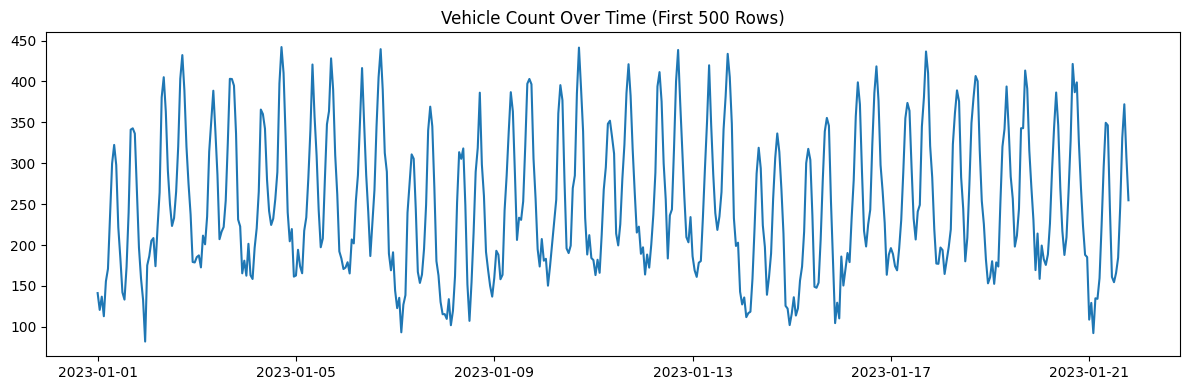

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"].iloc[:500], df["vehicle_count"].iloc[:500])
plt.title("Vehicle Count Over Time (First 500 Rows)")
plt.tight_layout()
plt.show()

### **Plot Average Speed Over Time:**

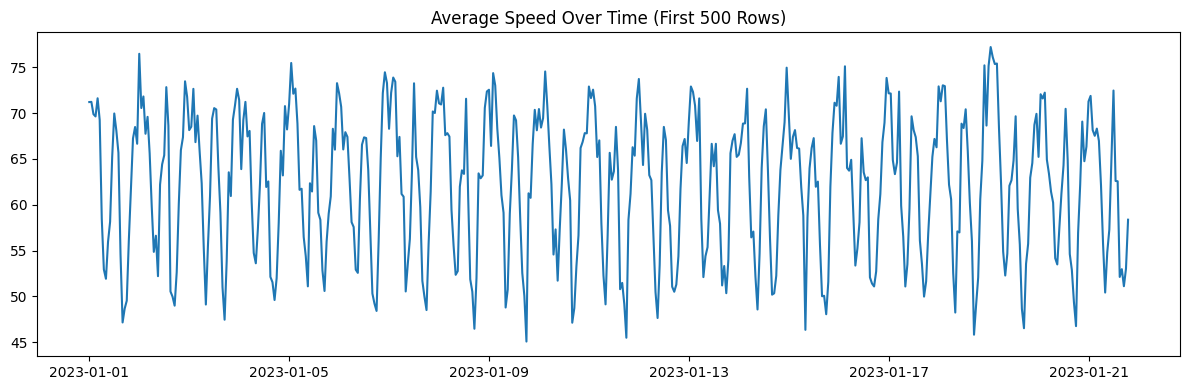

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"].iloc[:500], df["avg_speed"].iloc[:500])
plt.title("Average Speed Over Time (First 500 Rows)")
plt.tight_layout()
plt.show()

### **Plot Congestion Index Over Time:**

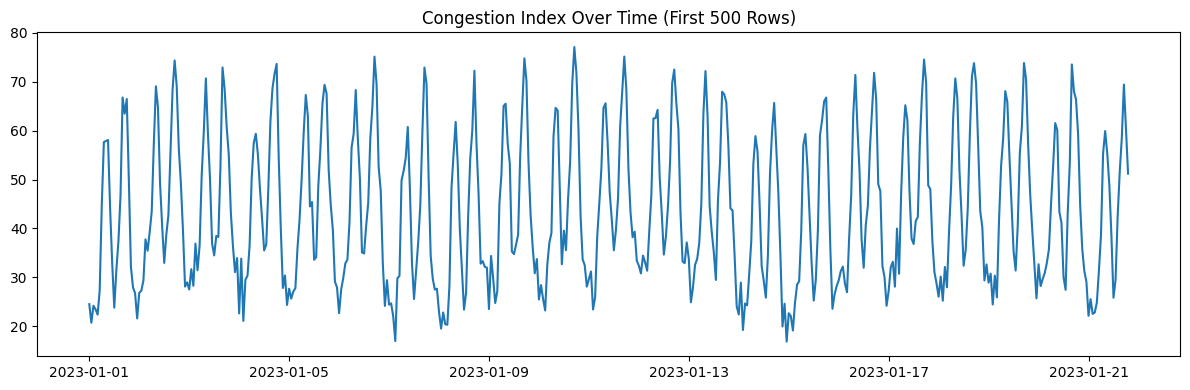

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"].iloc[:500], df["congestion_index"].iloc[:500])
plt.title("Congestion Index Over Time (First 500 Rows)")
plt.tight_layout()
plt.show()

### **Hourly Congestion Pattern:**

In [12]:
hourly_cong = df.groupby("hour")["congestion_index"].mean()
hourly_cong

hour
0     27.772194
1     27.775998
2     27.589810
3     28.117221
4     30.332259
5     36.131068
6     46.853010
7     59.414809
8     65.194791
9     59.496009
10    46.972270
11    36.445774
12    31.818415
13    34.264081
14    41.750696
15    54.357417
16    66.379317
17    71.484510
18    66.467246
19    54.223476
20    42.032506
21    33.827864
22    29.522213
23    27.949863
Name: congestion_index, dtype: float64

### **Plot Hourly Congestion Pattern:**

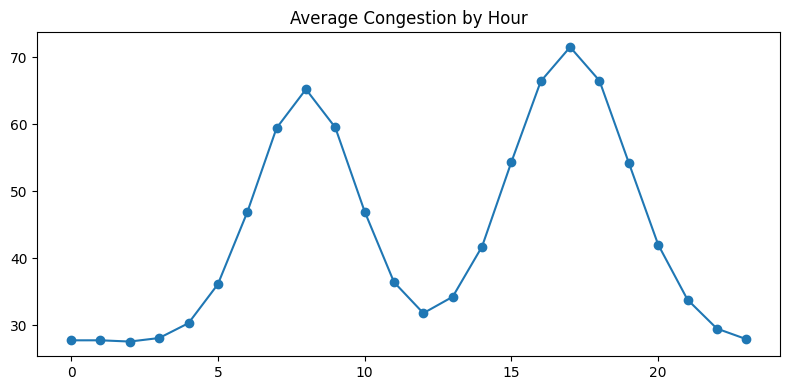

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(hourly_cong.index, hourly_cong.values, marker="o")
plt.title("Average Congestion by Hour")
plt.tight_layout()
plt.show()

### **Weekend vs Weekday Congestion:**

In [14]:
weekend_summary = df.groupby("weekend")["congestion_index"].mean()
weekend_summary

weekend
0    45.296987
1    39.365032
Name: congestion_index, dtype: float64

### **Plot Weekend vs Weekday Congestion:**

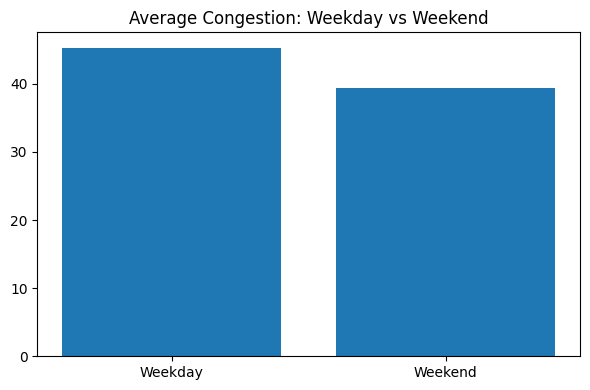

In [15]:
plt.figure(figsize=(6, 4))
plt.bar(["Weekday", "Weekend"], weekend_summary.values)
plt.title("Average Congestion: Weekday vs Weekend")
plt.tight_layout()
plt.show()

### **Correlation Analysis:**

In [16]:
corr_df = df[["vehicle_count","avg_speed","occupancy","weather_severity","congestion_index","hour",
              "dayofweek","weekend","hour_sin","hour_cos","dow_sin","dow_cos"]].corr()
corr_df

,vehicle_count,avg_speed,occupancy,weather_severity,congestion_index,hour,dayofweek,weekend,hour_sin,hour_cos,dow_sin,dow_cos
vehicle_count,1.000000,-0.865104,0.888675,0.006923,0.966058,2.383101e-01,-2.516325e-01,-3.171211e-01,-2.055676e-01,-4.667788e-01,2.509576e-01,-5.779012e-02
avg_speed,-0.865104,1.000000,-0.905601,-0.178967,-0.914433,-2.595044e-01,-4.977037e-03,-4.045369e-03,2.439279e-01,4.622759e-01,2.047976e-03,1.808449e-03
occupancy,0.888675,-0.905601,1.000000,0.118095,0.946095,2.569790e-01,-7.895537e-05,-3.070895e-03,-2.349471e-01,-4.719871e-01,3.370112e-03,-3.513211e-03
weather_severity,0.006923,-0.178967,0.118095,1.000000,0.067400,-9.417064e-03,-4.717620e-03,-6.957149e-03,3.025010e-04,-1.143314e-02,1.177124e-02,-1.468873e-03
congestion_index,0.966058,-0.914433,0.946095,0.067400,1.000000,2.524909e-01,-1.396977e-01,-1.767064e-01,-2.254758e-01,-4.757838e-01,1.411909e-01,-3.137143e-02
hour,0.238310,-0.259504,0.256979,-0.009417,0.252491,1.000000e+00,3.474246e-17,3.876334e-17,-7.759122e-01,-1.021508e-01,-4.456354e-17,1.172784e-17
dayofweek,-0.251632,-0.004977,-0.000079,-0.004718,-0.139698,3.474246e-17,1.000000e+00,7.919144e-01,-5.197907e-18,5.045817e-18,-7.352085e-01,-3.484852e-01
weekend,-0.317121,-0.004045,-0.003071,-0.006957,-0.176706,3.876334e-17,7.919144e-01,1.000000e+00,5.572898e-18,-3.088355e-18,-7.864273e-01,1.823203e-01
hour_sin,-0.205568,0.243928,-0.234947,0.000303,-0.225476,-7.759122e-01,-5.197907e-18,5.572898e-18,1.000000e+00,-2.363660e-17,2.122221e-18,5.134461e-19
hour_cos,-0.466779,0.462276,-0.471987,-0.011433,-0.475784,-1.021508e-01,5.045817e-18,-3.088355e-18,-2.363660e-17,1.000000e+00,2.001856e-18,-7.099501e-19


### **Plot Correlation Heatmap:**

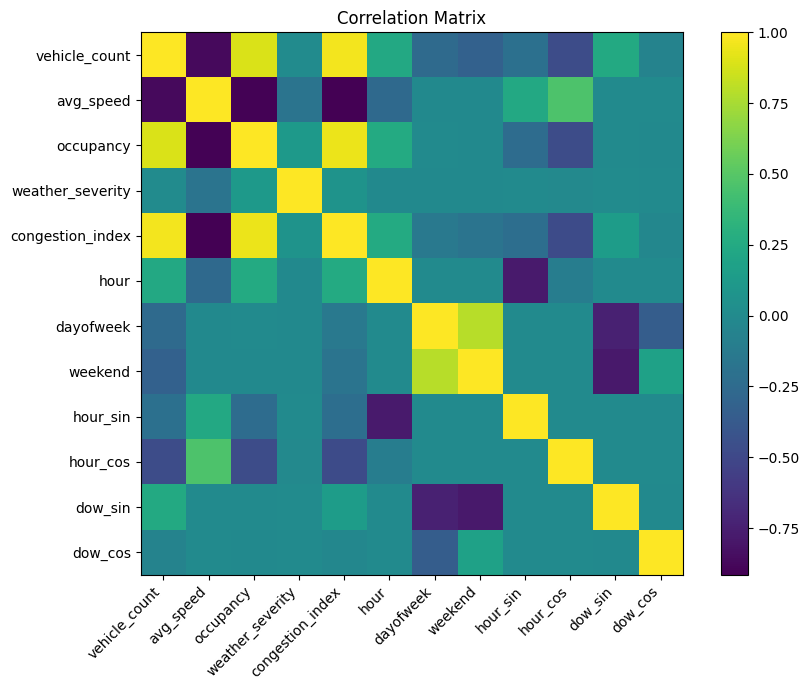

In [17]:
plt.figure(figsize=(9, 7))
plt.imshow(corr_df, interpolation="nearest")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_df.columns)), corr_df.columns)
plt.title("Correlation Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

### **Select Features and Target:**

In [18]:
target_col = "congestion_index"
feature_cols = ["congestion_index","vehicle_count","avg_speed","occupancy","weather_severity","hour_sin","hour_cos","dow_sin","dow_cos","weekend"]
feature_cols

['congestion_index',
 'vehicle_count',
 'avg_speed',
 'occupancy',
 'weather_severity',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'weekend']

### **Train / Validation / Test Split:**

In [19]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(train_df.shape, val_df.shape, test_df.shape)

(6132, 13) (1314, 13) (1314, 13)


### **Scale Features:**

In [20]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(train_df[feature_cols])
val_features_scaled = feature_scaler.transform(val_df[feature_cols])
test_features_scaled = feature_scaler.transform(test_df[feature_cols])

train_target_scaled = target_scaler.fit_transform(train_df[[target_col]])
val_target_scaled = target_scaler.transform(val_df[[target_col]])
test_target_scaled = target_scaler.transform(test_df[[target_col]])

print(train_features_scaled.shape)

(6132, 10)


### **Define Sequence Builder:**

In [21]:
def build_sequences(features, target, seq_len=24):
    X, y = [], []
    for i in range(seq_len, len(features)):
        X.append(features[i-seq_len:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

### **Build Sequences:**

In [22]:
SEQ_LEN = 24
X_train, y_train = build_sequences(train_features_scaled, train_target_scaled, seq_len=SEQ_LEN)
X_val, y_val = build_sequences(val_features_scaled, val_target_scaled, seq_len=SEQ_LEN)
X_test, y_test = build_sequences(test_features_scaled, test_target_scaled, seq_len=SEQ_LEN)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(6108, 24, 10) (6108,)
(1290, 24, 10) (1290,)
(1290, 24, 10) (1290,)


### **Inspect One Sequence:**

In [23]:
pd.DataFrame(X_train[0], columns=feature_cols).head()

,congestion_index,vehicle_count,avg_speed,occupancy,weather_severity,hour_sin,hour_cos,dow_sin,dow_cos,weekend
0,-1.256105,-1.272887,1.165422,-0.979033,0.294560,-0.001752,1.413983,-1.108606,0.869809,1.581139
1,-1.506024,-1.511653,1.168115,-1.179444,-1.154296,0.364274,1.365795,-1.108606,0.869809,1.581139
2,-1.277466,-1.323905,0.994313,-0.921477,0.774819,0.705356,1.224514,-1.108606,0.869809,1.581139
3,-1.324629,-1.601958,0.962203,-0.610434,0.979658,0.998250,0.999769,-1.108606,0.869809,1.581139
4,-1.396904,-1.105255,1.218660,-1.324659,-1.530225,1.222995,0.706876,-1.108606,0.869809,1.581139


### **Build Baseline Predictions:**

In [24]:
baseline_val_pred_scaled = X_val[:, -1, 0]
baseline_test_pred_scaled = X_test[:, -1, 0]

### **Inverse Target Helper:**

In [25]:
def inverse_target(arr_1d):
    return target_scaler.inverse_transform(arr_1d.reshape(-1, 1)).reshape(-1)

### **Convert Baseline Predictions to Original Scale:**

In [26]:
y_val_actual = inverse_target(y_val)
y_test_actual = inverse_target(y_test)

baseline_val_pred = inverse_target(baseline_val_pred_scaled)
baseline_test_pred = inverse_target(baseline_test_pred_scaled)

### **Baseline Metrics:**

In [27]:
baseline_val_mae = mean_absolute_error(y_val_actual, baseline_val_pred)
baseline_val_rmse = mean_squared_error(y_val_actual, baseline_val_pred) ** 0.5
baseline_test_mae = mean_absolute_error(y_test_actual, baseline_test_pred)
baseline_test_rmse = mean_squared_error(y_test_actual, baseline_test_pred) ** 0.5

print(baseline_val_mae, baseline_val_rmse, baseline_test_mae, baseline_test_rmse)

7.571198024905361 9.249835734025918 7.596779602270479 9.18380922513876


### **Build Stacked LSTM Model:**

In [28]:
def build_stacked_lstm(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32, return_sequences=True),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(16),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

### **Instantiate Stacked LSTM:**

In [29]:
lstm_model = build_stacked_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 24, 64)              │          19,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 24, 32)              │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 35,041 (136.88 KB)

 Trainable params: 35,041 (136.88 KB)

 Non-trainable params: 0 (0.00 B)

### **Training Callbacks:**

In [30]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

### **Train Stacked LSTM:**

In [31]:
history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.4554 - mae: 0.5333 - val_loss: 0.1054 - val_mae: 0.2557 - learning_rate: 0.0010
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0877 - mae: 0.2351 - val_loss: 0.0738 - val_mae: 0.2140 - learning_rate: 0.0010
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0791 - mae: 0.2238 - val_loss: 0.0728 - val_mae: 0.2139 - learning_rate: 0.0010
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0754 - mae: 0.2185 - val_loss: 0.0633 - val_mae: 0.2008 - learning_rate: 0.0010
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0712 - mae: 0.2128 - val_loss: 0.0700 - val_mae: 0.2096 - learning_rate: 0.0010
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0689 - mae: 0.2095 - val_loss: 0.0602 - val_mae: 0.1938 - learning_rate: 0.0010
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0679 - mae: 0.2067 - val_loss: 0.0564 - val_mae: 0.1890 - learning_rate: 0.0010
Epoch 8/20
96

### **Plot Training vs Validation Loss:**

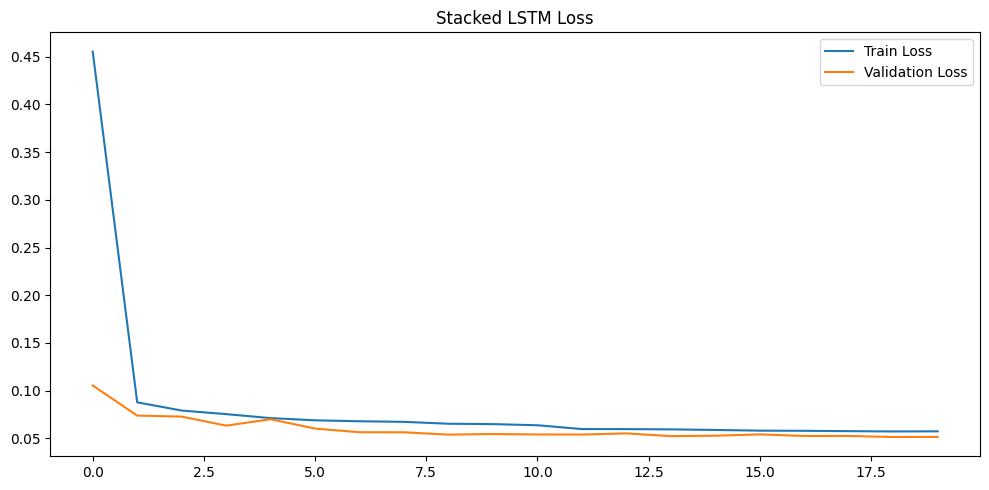

In [32]:
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Stacked LSTM Loss")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Training vs Validation MAE:**

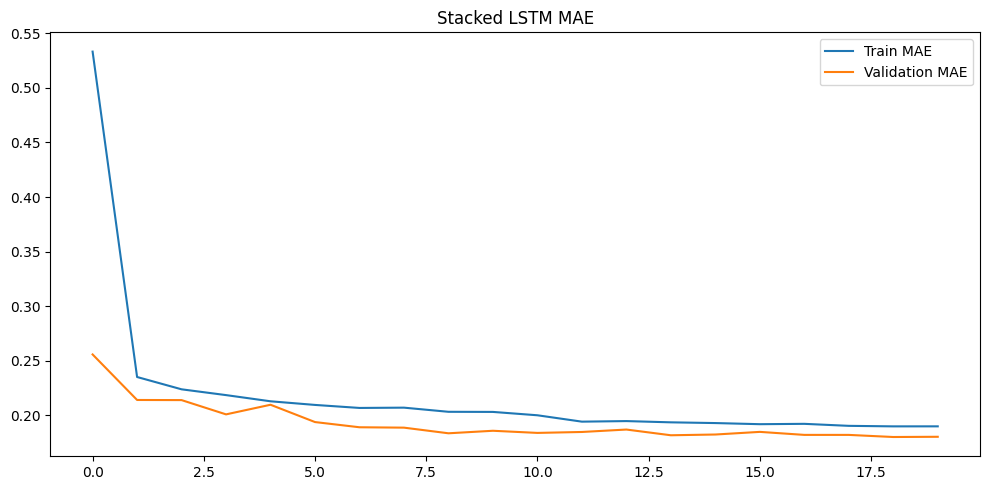

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["mae"], label="Train MAE")
plt.plot(history_df["val_mae"], label="Validation MAE")
plt.title("Stacked LSTM MAE")
plt.legend()
plt.tight_layout()
plt.show()

### **Predict Validation and Test Sets:**

In [34]:
val_pred_scaled = lstm_model.predict(X_val, verbose=0).reshape(-1)
test_pred_scaled = lstm_model.predict(X_test, verbose=0).reshape(-1)

val_pred = inverse_target(val_pred_scaled)
test_pred = inverse_target(test_pred_scaled)

### **Validation Metrics:**

In [35]:
val_mae = mean_absolute_error(y_val_actual, val_pred)
val_rmse = mean_squared_error(y_val_actual, val_pred) ** 0.5
val_r2 = r2_score(y_val_actual, val_pred)

print(val_mae, val_rmse, val_r2)

2.7322426530827455 3.4389905024159058 0.9493119604090813


### **Test Metrics:**

In [36]:
test_mae = mean_absolute_error(y_test_actual, test_pred)
test_rmse = mean_squared_error(y_test_actual, test_pred) ** 0.5
test_r2 = r2_score(y_test_actual, test_pred)

print(test_mae, test_rmse, test_r2)

2.691659451569304 3.379029084292698 0.9508788261846497


### **Compare Baseline vs LSTM:**

In [37]:
comparison_df = pd.DataFrame({
    "Model": ["Persistence Baseline", "Stacked LSTM"],
    "Validation_MAE": [baseline_val_mae, val_mae],
    "Validation_RMSE": [baseline_val_rmse, val_rmse],
    "Test_MAE": [baseline_test_mae, test_mae],
    "Test_RMSE": [baseline_test_rmse, test_rmse]
})
comparison_df

,Model,Validation_MAE,Validation_RMSE,Test_MAE,Test_RMSE
0,Persistence Baseline,7.571198,9.249836,7.596780,9.183809
1,Stacked LSTM,2.732243,3.438991,2.691659,3.379029


### **Plot Actual vs Predicted (Validation):**

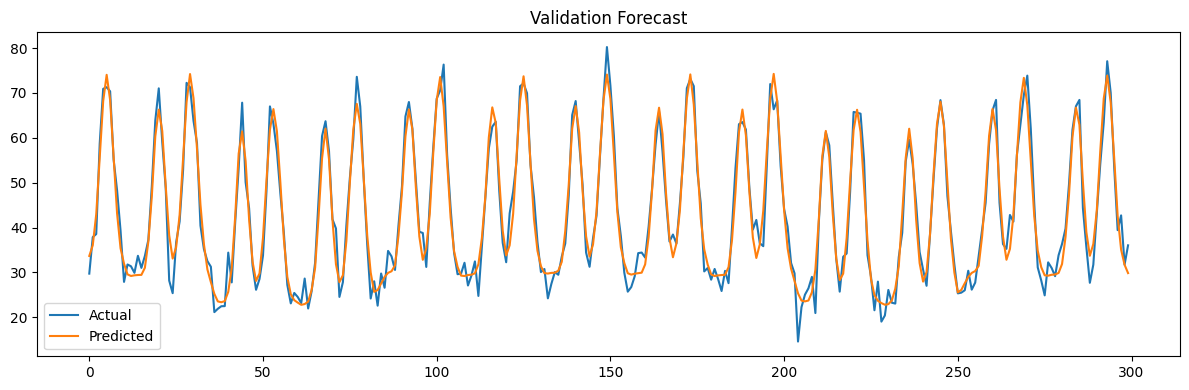

In [38]:
plt.figure(figsize=(12, 4))
plt.plot(y_val_actual[:300], label="Actual")
plt.plot(val_pred[:300], label="Predicted")
plt.title("Validation Forecast")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Actual vs Predicted (Test):**

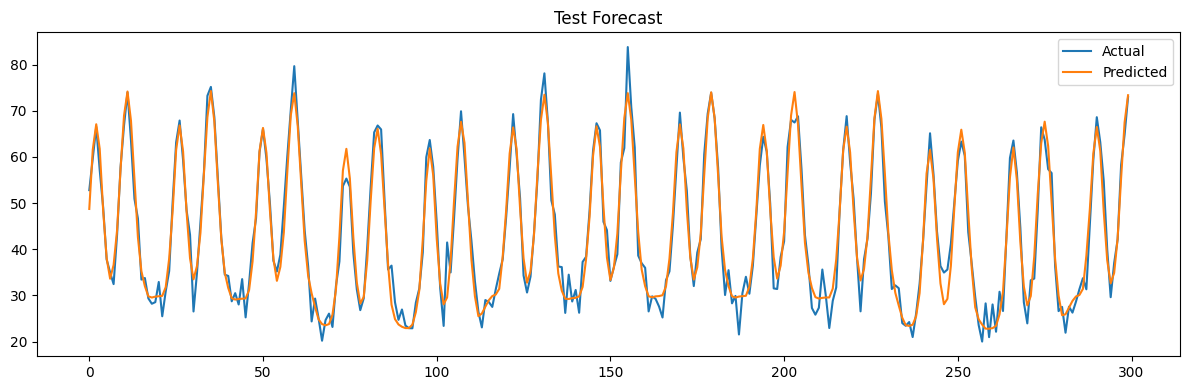

In [39]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_actual[:300], label="Actual")
plt.plot(test_pred[:300], label="Predicted")
plt.title("Test Forecast")
plt.legend()
plt.tight_layout()
plt.show()

### **Residual Analysis:**

In [40]:
residuals = y_test_actual - test_pred
pd.Series(residuals).describe()

count    1290.000000
mean        0.199885
std         3.374420
min       -10.446897
25%        -2.084118
50%         0.220536
75%         2.448749
max        11.911064
dtype: float64

### **Plot Residual Distribution:**

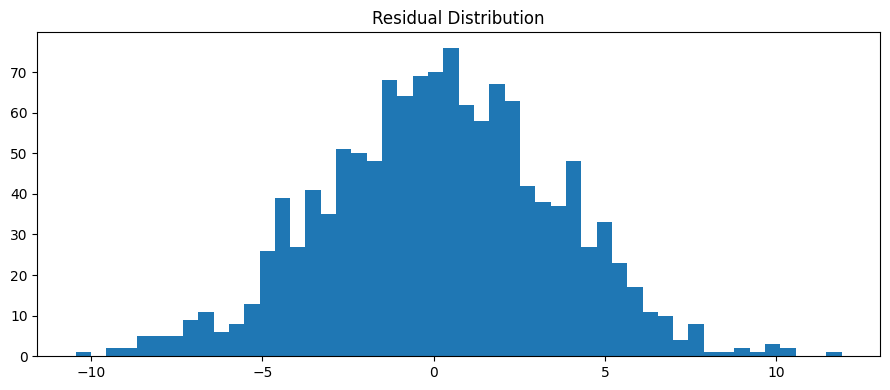

In [41]:
plt.figure(figsize=(9, 4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

### **Plot Residuals Over Time:**

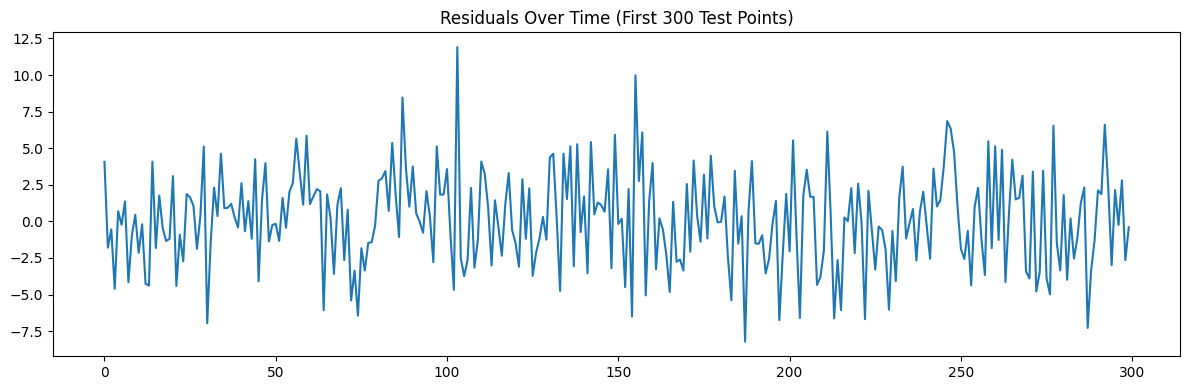

In [42]:
plt.figure(figsize=(12, 4))
plt.plot(residuals[:300])
plt.title("Residuals Over Time (First 300 Test Points)")
plt.tight_layout()
plt.show()

### **Congestion Regime Analysis:**

In [43]:
regime = pd.cut(y_test_actual, bins=[-np.inf, 35, 60, np.inf], labels=["low","medium","high"])
regime_error_df = pd.DataFrame({"regime": regime, "abs_error": np.abs(residuals)})
regime_summary = regime_error_df.groupby("regime")["abs_error"].mean()
regime_summary

regime
low       2.555675
medium    2.794988
high      2.729979
Name: abs_error, dtype: float64

### **Plot Error by Congestion Regime:**

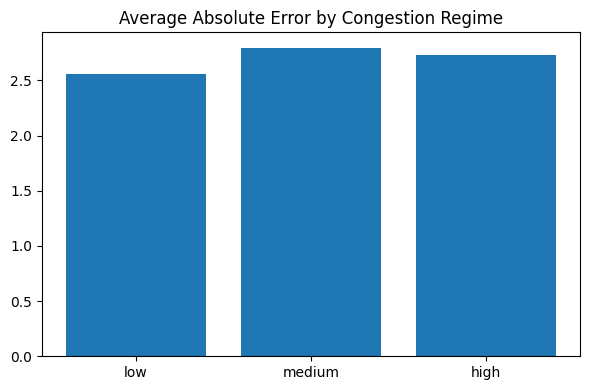

In [44]:
plt.figure(figsize=(6, 4))
plt.bar(regime_summary.index.astype(str), regime_summary.values)
plt.title("Average Absolute Error by Congestion Regime")
plt.tight_layout()
plt.show()

### **Error by Hour:**

In [45]:
test_hours = test_df["hour"].iloc[SEQ_LEN:].reset_index(drop=True)
hour_error_df = pd.DataFrame({"hour": test_hours, "abs_error": np.abs(residuals)})
hour_error_summary = hour_error_df.groupby("hour")["abs_error"].mean()
hour_error_summary

hour
0     2.418601
1     2.354660
2     2.742497
3     2.893967
4     2.776024
5     2.387317
6     2.865695
7     3.021074
8     2.415173
9     2.248082
10    2.789785
11    2.804954
12    2.716399
13    2.852711
14    2.012829
15    3.002420
16    2.724834
17    3.299795
18    2.593924
19    2.647786
20    2.701557
21    2.691528
22    2.597978
23    3.029554
Name: abs_error, dtype: float64

### **Plot Error by Hour:**

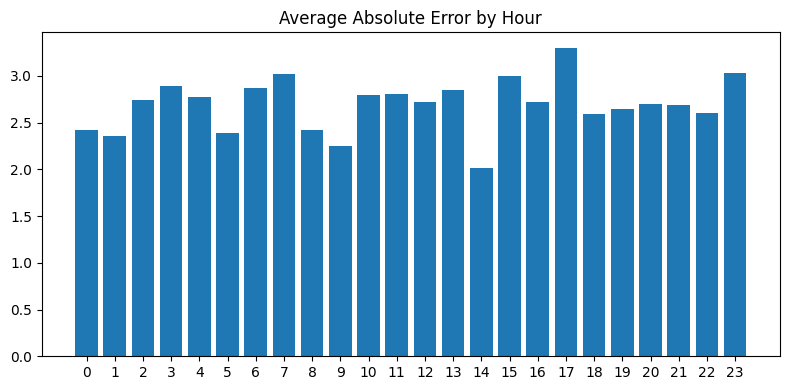

In [46]:
plt.figure(figsize=(8, 4))
plt.bar(hour_error_summary.index.astype(str), hour_error_summary.values)
plt.title("Average Absolute Error by Hour")
plt.tight_layout()
plt.show()

### **Best Prediction Examples:**

In [47]:
best_idx = np.argsort(np.abs(residuals))[:10]
best_idx[:10]

array([ 790,  450,  690, 1093,  838,   92,  217,  650,  180,  753],
      dtype=int64)

### **Worst Prediction Examples:**

In [48]:
worst_idx = np.argsort(np.abs(residuals))[-10:]
worst_idx[:10]

array([1230,  640,  316,  486, 1181,  155,  905,  669, 1043,  103],
      dtype=int64)

### **Sample Forecast Table:**

In [49]:
sample_df = pd.DataFrame({
    "actual": y_test_actual[:20],
    "predicted": test_pred[:20],
    "residual": residuals[:20]
})
sample_df

,actual,predicted,residual
0,52.810119,48.741024,4.069095
1,59.770936,61.565887,-1.794951
2,66.530795,67.082642,-0.551847
3,57.153868,61.763702,-4.609834
4,49.022387,48.328171,0.694216
5,37.796750,38.029575,-0.232826
6,34.987854,33.626205,1.361649
7,32.458318,36.614586,-4.156268
8,43.162484,44.129341,-0.966858
9,57.793529,57.343521,0.450008


### **Save Model Artifacts:**

In [50]:
model_path = MODEL_DIR / "stacked_lstm_traffic.keras"
scaler_path = MODEL_DIR / "scalers.json"

lstm_model.save(model_path)

scaler_meta = {
    "feature_mean": feature_scaler.mean_.tolist(),
    "feature_scale": feature_scaler.scale_.tolist(),
    "target_mean": target_scaler.mean_.tolist(),
    "target_scale": target_scaler.scale_.tolist(),
    "feature_cols": feature_cols,
    "seq_len": SEQ_LEN
}
with open(scaler_path, "w") as f:
    json.dump(scaler_meta, f, indent=4)

print(model_path)
print(scaler_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Traffic Flow Prediction using Stacked LSTM\artifacts_lstm_traffic\models\stacked_lstm_traffic.keras
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\LSTM Model\Traffic Flow Prediction using Stacked LSTM\artifacts_lstm_traffic\models\scalers.json


### **Reload Model for Inference Check:**

In [51]:
reloaded_model = tf.keras.models.load_model(model_path)
sample_pred = reloaded_model.predict(X_test[:5], verbose=0)
sample_pred.shape

(5, 1)

### **Final Metrics Summary Table:**

In [52]:
summary_table = pd.DataFrame({
    "Metric": ["Baseline Test MAE","Baseline Test RMSE","LSTM Test MAE","LSTM Test RMSE","LSTM Test R2"],
    "Value": [baseline_test_mae, baseline_test_rmse, test_mae, test_rmse, test_r2]
})
summary_table

,Metric,Value
0,Baseline Test MAE,7.596780
1,Baseline Test RMSE,9.183809
2,LSTM Test MAE,2.691659
3,LSTM Test RMSE,3.379029
4,LSTM Test R2,0.950879


### **Project Summary**

This project presents a complete implementation of a **Traffic Flow Prediction System using Deep Stacked LSTM Networks**, focusing on forecasting traffic conditions.

The workflow begins with preprocessing time-series data, including normalization and sequence preparation.

The core of the system is a **Deep Stacked LSTM Model**, which consists of:

### **1. Sequence Input Layer**

- Converts traffic data into sequences  

### **2. Stacked LSTM Layers**

- Multiple LSTM layers stacked  
- Capture hierarchical temporal features  

### **3. Dense Output Layer**

- Predicts future traffic flow values  

The model learns:
- temporal dependencies  
- traffic trends  
- seasonal patterns  

A key strength of this project is:

- **Deep temporal modeling**
  - captures complex patterns  

- **Scalability**
  - suitable for large datasets  

Evaluation is performed using:

- Mean Squared Error (MSE)  
- Root Mean Squared Error (RMSE)  

The system can be used in real-world applications to:

- predict traffic congestion  
- optimize routes  
- improve transportation planning  

Overall, this project demonstrates strong AI capabilities and showcases the ability to build **deep learning-based traffic forecasting systems**.

### **Key Highlights**

- Built a **Traffic Flow Prediction system using Deep Stacked LSTM**, targeting time-series forecasting applications.

- Addressed real-world problem:
  - forecasting traffic conditions  

- Utilized dataset with:
  - time-series traffic data  

- Implemented a complete **data preprocessing pipeline**, including:
  - normalization  
  - sequence generation  

- Leveraged **Stacked LSTM architecture**, enabling:
  - deep temporal modeling  

- Designed a **forecasting system**, enabling:
  - prediction of future traffic values  

- Developed a **time-series model**, capable of:
  - capturing trends and seasonality  

- Evaluated model performance using:
  - MSE, RMSE  

- Enabled **real-world applications**, including:
  - smart cities  
  - navigation systems  
  - transportation analytics  

- Designed for **deployment scenarios**, including:
  - traffic dashboards  
  - forecasting APIs  

- Demonstrates strong expertise in:
  - **time-series forecasting**  
  - **deep learning (LSTM)**  
  - **temporal modeling**